**개념 정리**

군집: 비슷한 샘플을 클러스터로 모음

이상치 탐지: '정상' 데이터가 어떻게 보이는지를 학습, 비정상 샘플을 감지하는 데 사용

밀도 추정: 데이터셋 생성 확률 과정의 확률 밀도 함수를 추정

## 9.1 군집

군집: 비슷한 샘플을 구별해 하나의 클러스터 또는 비슷한 샘플의 그룹으로 할당하는 작업
- 고객 분류, 데이터 분석, 차원 축소 기법, 이상치 탐지, 준지도 학습, 검색 엔진, 이미지 분할 등의 애플리케이션에서 사용
- 알고리즘이 다르면 다른 종류의 클러스터를 감지
    - 어떤 알고리즘은 센트로이드라 부르는 특정 포인트를 중심으로 모인 샘플을 찾음
    - 어떤 알고리즘은 샘플이 밀집되어 연속된 영역을 찾음
    - 어떤 알고리즘은 계층적으로 클러스터의 클러스터를 찾음

### 9.1.1 k-평균

k-평균: 반복 몇 번으로 레이블 없는 데이터셋을 빠르고 효율적으로 클러스터로 묶을 수 있는 간단한 알고리즘
- 알고리즘이 찾을 클러스터 개수를 지정해야 함
- 군집에서 각 샘플의 레이블은 알고리즘이 샘플에 할당한 클러스터의 인덱스
- 클러스터의 크기가 많이 다르면 잘 작동 X
- 소프트 군집: 하드 군집이라는 샘플을 하나의 클러스터에 할당하는 것보다 클러스터마다 샘플에 점수를 부여하는 것이 유용
    - 해당 점수는 샘플과 센트로이드 사이의 거리 가능, 가우시안 방사기저 함수와 같은 유사도 점수도 가능

k-평균 알고리즘
- 센트로이드를 랜덤하게 선정 -> 샘플에 레이블 할당, 센트로이드 업데이트 -> 센트로이드에 변화가 없을 때까지 반복 (제한된 횟수 안에 수렴 보장)

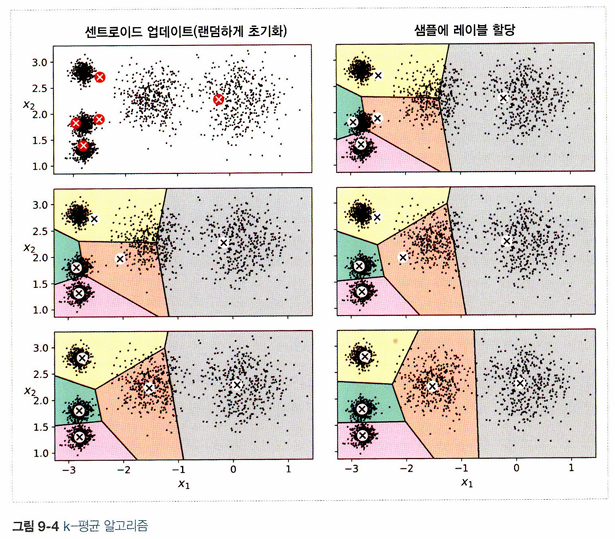

센트로이드 초기화 방법
- 위치를 근사하게 알 수 있다면 init 매개변수에 센트로이드 리스트를 담은 넘파이 배열 지정, n_init을 1로 설정
- 랜덤 초기화를 다르게 하여 여러 번 알고리즘을 실행하고 가장 좋은 솔루션을 선택
    - 이너셔: 각 샘플과 가장 가까운 센트로이드 사이의 평균 제곱 거리
- 다른 센트로이드와 거리가 먼 센트로이드를 선택하는 똑똑한 초기화 단계
    - k-평균 알고리즘이 최적이 아닌 솔루션으로 수렴할 가능성을 크게 낮춤

k-평균 속도 개선과 미니배치 k-평균
- k-평균 알고리즘 개선
    - 불필요한 거리 계산을 피하면 속도 높이기 가능
        - 삼각 부등식 사용, 샘플과 센트로이드 사이의 거리를 위한 하한선과 상한선 유지
    - 전체 데이터셋을 반복하지 않고 각 반복마다 미니배치를 사용해 센트로이드를 조금씩 이동
        - MiniBatchKMeans클래스에 구현
- 미니배치 k-평균이 일반 k-평균보다 빠르지만 이너셔는 일반적으로 조금 더 나쁨

최적의 클러스터 개수 찾기
- 이너셔는 k가 증가함에 따라 작아짐, k를 선택할 때 좋은 성능 지표 X
- 실루엣 점수: 모든 샘플에 대한 실루엣 계수의 평균
    - 실루엣 계수 계산: (b-a) / max(a,b)
        - a: 동일한 클러스터에 있는 다른 샘플까지 평균 거리
        - b: 가장 가까운 클러스터까지 평균 거리
        - -1에서 +1까지 변동 가능
- 실루엣 다이어그램: 모든 샘플의 실루엣 계수를 할당된 클러스터와 계숫값으로 정렬하여 더 많은 정보를 얻을 수 있는 그래프
    - 높이: 클러스터가 포함하고 있는 샘플의 개수
    - 너비: 클러스터에 포함된 샘플의 정렬된 실루엣 계수
    - 수직 파선: 각 클러스터 개수에 해당하는 실루엣 점수

### 9.1.2 k-평균의 한계

- 최적이 아닌 솔루션을 피하려면 알고리즘을 여러 번 실행해야 하고 클러스터 개수 지정이 필요해서 번거로움
- 클러스터의 크기나 밀집도가 서로 다르거나 원형이 아닐 경우 잘 작동 X

### 9.1.3 군집을 이용한 이미지 분할

- 이미지 분할: 이미지를 세그먼트 여러 개로 분할하는 작업
- 시맨틱 분할: 동일한 종류의 물체에 속한 모든 픽셀은 같은 세그먼트에 할당
- 색상 분할: 동일한 색상을 가진 픽셀을 같은 세그먼트에 할당

### 9.1.4 군집을 사용한 전처리

- 군집은 차원 축소에 효과적인 방법

### 9.1.5 군집을 사용한 준지도 학습

- 레이블이 없는 데이터가 많고 레이블이 있는 데이터는 적을 때 군집을 사용
- 대표 이미지: 각 클러스터에서 센트로이드에 가장 가까운 이미지
- 레이블 전파: 레이블을 동일한 클러스터에 있는 모든 샘플로 전파
- 능동 학습: 모델과 훈련 세트를 지속적으로 향상하기 위해 다음 단계로 반복
    - 불확실성 샘플링 사용: 지금까지 수집한 레이블된 샘플에서 모델을 훈련 -> 레이블되지 않은 모든 샘플에 대한 예측 생성 -> 가장 불확실하게 예측한 샘플을 전문가에게 보내 레이블 부여 -> 성능이 향상되지 않을 때까지 반복

### 9.1.6 DBSCAN

DBSCAN: 밀집된 연속적 지역을 클러스터로 정의
- 각 샘플에서 작은 거리인 입실론 내에 샘플이 몇 개 놓여 있는지 셈 -> 적어도 min_samples개 샘플이 있다면 핵심 샘플로 간주 -> 핵심 샘플의 이웃에 있는 모든 샘플은 동일한 클러스터에 속함 -> 핵심 샘플도 이웃도 아닌 샘플은 이상치로 판단
- 클러스터의 모양과 개수에 상관없이 감지 가능
- 계산 복잡도 대략 O(m log m)

### 9.1.7 다른 군집 알고리즘

병합 군집: 클러스터 계층을 밑바닥부터 위로 쌓아 구성
- 반복마다 인접한 클러스터 쌍을 연결
- 병합된 클러스터 쌍을 트리로 모두 그리면 이진 트리를 얻을 수 있음
- 대규모 샘플과 클러스터에 잘 확장, 다양한 형태의 클러스터 감지 가능

BIRCH: 대규모 데이터셋을 위해 고안
- 훈련 과정에서 새로운 샘플을 클러스터에 빠르게 할당할 수 있는 정보를 담은 트리 구조를 만듦

평균-이동: 각 샘플을 중심으로 하는 원을 그리고 원마다 안에 포함된 모든 샘플의 평균을 구함 -> 원의 중심을 평균점으로 이동
- 지역의 최대 밀도를 찾을 때까지 높은 쪽으로 원을 이동
- 하이퍼파라미터가 밴드위스 하나임

유사도 전파: 투표 방식 사용
- 샘플은 자신을 대표할 수 있는 비슷한 샘플에 투표

스펙트럼 군집: 샘플 사이의 유사도 행렬을 받아 저차원 임베딩을 만듦
- 복잡한 클러스터 구조 감지, 크래프 컷을 찾는 데 사용

**코드 필사**

In [14]:
#데이터 불러오기
from sklearn.datasets import make_blobs
import numpy as np

#make_blobs()의 정확한 인수는 중요하지 않습니다.
blob_centers=np.array([[0.2, 2.3], [-1.5, 2.3],
                       [-2.8, 1.8], [-2.8, 2.8], [-2.8, 1.3]])
blob_std=np.array([0.4, 0.3, 0.1, 0.1, 0.1])
X, y=make_blobs(n_samples=2000, centers=blob_centers,
                cluster_std=blob_std, random_state=7)

k-평균

In [15]:
from sklearn.cluster import KMeans
k=5
kmeans=KMeans(n_clusters=k)
y_pred=kmeans.fit_predict(X)

In [16]:
y_pred

array([1, 1, 2, ..., 4, 2, 1], dtype=int32)

In [17]:
y_pred is kmeans.labels_

True

In [18]:
kmeans.cluster_centers_

array([[-1.47468607,  2.28399066],
       [-2.80214068,  1.55162671],
       [ 0.47392583,  2.42318082],
       [-0.05718322,  2.10248968],
       [-2.79290307,  2.79641063]])

In [19]:
X_new=np.array([[0,2], [3,2], [-3,3], [-3,2.5]])
kmeans.predict(X_new)

array([3, 2, 4, 4], dtype=int32)

In [20]:
kmeans.transform(X_new)

array([[1.50178217, 2.83778629, 0.63536422, 0.11736292, 2.9042344 ],
       [4.48368889, 5.81943941, 2.5612756 , 3.05890068, 5.84739223],
       [1.685008  , 1.4618254 , 3.52148847, 3.07663702, 0.29040966],
       [1.54053323, 0.96879317, 3.47477508, 2.9695429 , 0.36159148]])

In [21]:
good_init=np.array([[-3,3], [-3,2], [-3,1], [-1,2], [0,2]])
kmeans=KMeans(n_clusters=5, init=good_init, n_init=1)

In [22]:
kmeans.fit_predict(X)
kmeans.inertia_

211.59853725816828

In [23]:
kmeans.score(X)

-211.59853725816828

In [24]:
from sklearn.cluster import MiniBatchKMeans

minibatch_kmeans=MiniBatchKMeans(n_clusters=5)
minibatch_kmeans.fit(X)

MiniBatchKMeans(n_clusters=5)

In [25]:
from sklearn.metrics import silhouette_score
silhouette_score(X, kmeans.labels_)

np.float64(0.655517642572828)

이미지 분할

In [26]:
import matplotlib.pyplot as plt
from matplotlib.image import imread # or 'from imageio import imread'
image=plt.imread("ladybug.png")
image.shape

(533, 800, 3)

In [27]:
X=image.reshape(-1,3)
kmeans=KMeans(n_clusters=8).fit(X)
segmented_img=kmeans.cluster_centers_[kmeans.labels_]
segmented_img=segmented_img.reshape(image.shape)

군집을 사용한 전처리



In [28]:
from sklearn.datasets import load_digits

X_digits, y_digits=load_digits(return_X_y=True)

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test=train_test_split(X_digits, y_digits)

In [30]:
from sklearn.linear_model import LogisticRegression

log_reg=LogisticRegression()
log_reg.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [31]:
log_reg.score(X_test, y_test)

0.9777777777777777

In [32]:
from sklearn.pipeline import Pipeline

pipeline=Pipeline([
    ("kmeans", KMeans(n_clusters=50)),
    ("log_reg", LogisticRegression()),
])
pipeline.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Pipeline(steps=[('kmeans', KMeans(n_clusters=50)),
                ('log_reg', LogisticRegression())])

In [33]:
pipeline.score(X_test, y_test)

0.9755555555555555

In [34]:
from sklearn.model_selection import GridSearchCV

param_grid=dict(kmeans__n_clusters=range(2,100))
grid_clf=GridSearchCV(pipeline, param_grid, cv=3, verbose=2)
grid_clf.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Fitting 3 folds for each of 98 candidates, totalling 294 fits
[CV] END ...............................kmeans__n_clusters=2; total time=   0.1s


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

[CV] END ...............................kmeans__n_clusters=2; total time=   0.1s
[CV] END ...............................kmeans__n_clusters=2; total time=   0.1s
[CV] END ...............................kmeans__n_clusters=3; total time=   0.1s


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

...

[CV] END ..............................kmeans__n_clusters=99; total time=   1.8s


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


[CV] END ..............................kmeans__n_clusters=99; total time=   2.4s


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('kmeans', KMeans(n_clusters=50)),
                                       ('log_reg', LogisticRegression())]),
             param_grid={'kmeans__n_clusters': range(2, 100)}, verbose=2)

In [35]:
grid_clf.best_params_

{'kmeans__n_clusters': 98}

In [36]:
grid_clf.score(X_test, y_test)

0.9666666666666667

군집을 사용한 준지도 학습

In [37]:
n_labeled=50
log_reg=LogisticRegression()
log_reg.fit(X_train[:n_labeled], y_train[:n_labeled])

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [38]:
log_reg.score(X_test, y_test)

0.7377777777777778

In [39]:
k=50
kmeans=KMeans(n_clusters=k)
X_digits_dist=kmeans.fit_transform(X_train)
representative_digit_idx=np.argmin(X_digits_dist, axis=0)
X_representative_digits=X_train[representative_digit_idx]

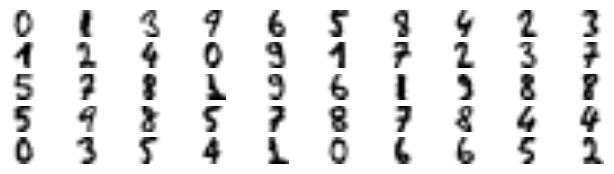

In [40]:
plt.figure(figsize=(8,2))
for index, X_representative_digit in enumerate(X_representative_digits):
    plt.subplot(k//10, 10, index+1)
    plt.imshow(X_representative_digit.reshape(8,8),
               cmap="binary", interpolation="bilinear")
    plt.axis('off')
plt.show()

In [41]:
y_representative_digits=np.array([0,1,3,9,6,5,8,4,2,3,
                                  1,2,4,0,9,1,7,2,3,7,
                                  5,7,8,3,9,6,1,9,8,8,
                                  5,9,8,5,7,8,7,8,4,4,
                                  0,3,5,4,2,0,6,6,5,2])

In [42]:
log_reg=LogisticRegression()
log_reg.fit(X_representative_digits, y_representative_digits)
log_reg.score(X_test, y_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.8844444444444445

In [43]:
y_train_propagated=np.empty(len(X_train), dtype=np.int32)
for i in range(k):
    y_train_propagated[kmeans.labels_==i]=y_representative_digits[i]

In [44]:
log_reg=LogisticRegression()
log_reg.fit(X_train, y_train_propagated)
log_reg.score(X_test, y_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.9022222222222223

In [45]:
percentile_closest=20
X_cluster_dist=X_digits_dist[np.arange(len(X_train)), kmeans.labels_]
for i in range(k):
    in_cluster=(kmeans.labels_==i)
    cluster_dist=X_cluster_dist[in_cluster]

    cutoff_distance=np.percentile(cluster_dist, percentile_closest)
    above_cutoff=(X_cluster_dist>cutoff_distance)
    X_cluster_dist[in_cluster & above_cutoff]=-1

partially_propagated=(X_cluster_dist!=-1)
X_train_partially_propagated=X_train[partially_propagated]
y_train_partially_propagated=y_train_propagated[partially_propagated]

In [46]:
log_reg=LogisticRegression()
log_reg.fit(X_train_partially_propagated, y_train_partially_propagated)
log_reg.score(X_test, y_test)

0.8977777777777778

In [47]:
np.mean(y_train_partially_propagated==y_train[partially_propagated])

np.float64(0.9721254355400697)

DBSCAN

In [48]:
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons

X,y=make_moons(n_samples=1000, noise=0.05)
dbscan=DBSCAN(eps=0.05, min_samples=5)
dbscan.fit(X)

DBSCAN(eps=0.05)

In [49]:
dbscan.labels_

array([ 0,  1,  2,  0,  0,  0,  3,  3,  3,  0,  0,  0,  0, -1,  3,  3,  4,
        5,  0,  0,  3,  1,  2,  1,  2,  0,  0,  0,  3,  5,  1, -1,  4,  2,
        0,  3,  3,  1,  3,  6,  3,  2,  1,  7,  2,  2,  1,  3,  2,  0,  0,
        3,  8,  3, -1,  3,  7,  3,  2,  0,  3,  3,  2,  7,  0,  3,  9,  3,
        0,  4,  0,  5,  6,  0,  3,  2,  0,  0,  6, 10,  2,  8,  0,  3,  4,
        7,  0,  7,  2,  0,  0,  0,  0,  3,  2, -1,  5,  3,  3,  0, 11,  4,
        3,  3,  1,  5,  3, 12,  7, -1, 13,  8,  8,  7,  7,  3,  0,  4,  5,
        0, -1,  0,  0,  0,  2,  6,  2,  3,  0,  8,  3, -1,  0,  2,  3,  0,
       -1,  3,  0,  8,  2,  3,  6, 12,  0, 12,  7, -1,  2,  0,  3,  3,  2,
        0,  0,  5,  2,  0,  6,  3,  8,  3,  0,  8,  3,  2,  0,  4,  0,  5,
        0,  0,  3,  5, -1,  8,  3,  3, -1,  0,  3,  0, 13, -1,  3,  0,  0,
        7,  5,  3,  0,  0,  1,  0,  3,  0,  0,  0,  4, -1,  7,  3,  5, -1,
        0,  0,  0,  3, -1, -1,  7,  3,  0,  3, 11,  0, -1,  3,  0,  2,  0,
        5,  4, 11, 13,  1

In [50]:
len(dbscan.core_sample_indices_)

796

In [51]:
dbscan.core_sample_indices_

array([  0,   1,   2,   3,   4,   6,   7,   8,   9,  10,  11,  12,  14,
        15,  16,  17,  18,  20,  21,  22,  23,  24,  25,  26,  27,  28,
        29,  30,  32,  33,  34,  35,  36,  37,  38,  39,  40,  41,  42,
        43,  44,  45,  47,  48,  49,  51,  52,  53,  55,  56,  58,  59,
        60,  61,  62,  63,  64,  65,  66,  68,  69,  71,  73,  74,  75,
        76,  77,  78,  79,  80,  81,  82,  83,  85,  86,  88,  89,  90,
        92,  93,  94,  96,  97,  98,  99, 100, 102, 103, 104, 105, 106,
       107, 108, 110, 112, 113, 114, 115, 117, 118, 119, 121, 122, 123,
       125, 126, 127, 128, 129, 130, 132, 133, 134, 135, 137, 138, 139,
       140, 141, 142, 143, 144, 146, 148, 149, 150, 151, 152, 153, 154,
       155, 156, 157, 158, 160, 161, 162, 163, 164, 165, 167, 168, 170,
       171, 172, 175, 176, 177, 179, 180, 181, 182, 184, 185, 187, 188,
       189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 200, 201, 202,
       204, 205, 206, 207, 210, 211, 212, 213, 214, 215, 217, 21

In [52]:
dbscan.components_

array([[ 1.33247861, -0.44285199],
       [ 1.94209813,  0.15354096],
       [-0.13436231,  0.95344253],
       ...,
       [ 0.2240466 ,  0.92890989],
       [ 0.45231518,  0.91066674],
       [ 1.51575391, -0.38920179]])

In [53]:
from sklearn.neighbors import KNeighborsClassifier

knn=KNeighborsClassifier(n_neighbors=50)
knn.fit(dbscan.components_, dbscan.labels_[dbscan.core_sample_indices_])

KNeighborsClassifier(n_neighbors=50)

In [54]:
X_new=np.array([[-0.5,0], [0,0.5], [1,-0.1], [2,1]])
knn.predict(X_new)

array([ 7,  4,  0, 13])

In [55]:
knn.predict_proba(X_new)

array([[0.04, 0.  , 0.  , 0.  , 0.14, 0.  , 0.02, 0.8 , 0.  , 0.  , 0.  ,
        0.  , 0.  , 0.  ],
       [0.  , 0.  , 0.14, 0.06, 0.44, 0.  , 0.  , 0.  , 0.  , 0.08, 0.  ,
        0.1 , 0.18, 0.  ],
       [0.54, 0.  , 0.  , 0.36, 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.1 ,
        0.  , 0.  , 0.  ],
       [0.  , 0.2 , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
        0.  , 0.  , 0.8 ]])

In [56]:
y_dist, y_pred_idx=knn.kneighbors(X_new, n_neighbors=1)
y_pred=dbscan.labels_[dbscan.core_sample_indices_][y_pred_idx]
y_pred[y_dist>0.2]=-1
y_pred.ravel()

array([-1, 11, 10, -1])